# Evaluación 4
Integrante 1: Leandro flores

Integrante 2: Pablo Águila

Integrante 3: Pablo Saavedra

Correo Electrónico integrante 1: leandro.flores2201@alumnos.ubiobio.cl

Correo Electrónico integrante 2: pablo.aguila1901@alumnos.ubiobio.cl

Correo Electrónico integrante 3: pablo.saavedra2201@alumnos.ubiobio.cl

Fecha de Creación: Junio de 2026
Versión: 1.1

# Descripción
Este notebook presenta el desarrollo de la Evaluación 4 correspondiente a la asignatura de Inteligencia Artificial, perteneciente a la carrera de Ingeniería Civil en Informática de la Universidad del Bío-Bío, sede Concepción.
El propósito es construir, optimizar y evaluar modelos de clasificación binaria (LogisticRegression y DecisionTreeClassifier) orientados a detectar transacciones fraudulentas en la fintech PaySecure, ajustando el umbral de decisión para equilibrar la precisión y el recall de acuerdo al contexto del negocio.

# Requisitos de Software
Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

kneed >= 0.8.6
pandas >= 1.5.0
numpy >= 1.23.0
matplotlib >= 3.6.0
seaborn >= 0.12.0
scikit-learn >= 1.2.0
plotly >= 5.0.0

import pandas as pd
print(pd.__version__)

In [31]:
!pip install kneed

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd

import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.base import BaseEstimator, TransformerMixin
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from kneed import KneeLocator

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

plt.rcParams['figure.figsize'] = (20, 10)
plt.style.use('ggplot')

In [33]:
# Descarga del dataset desde el repositorio
!wget -q https://raw.githubusercontent.com/Pablo-Aguila/Proyecto_Inteligencia_Artificial/refs/heads/main/data/data_clientes.csv

data = pd.read_csv('data_clientes.csv')

print(f'Dimensiones del dataset: {data.shape}')
print(f'Filas: {data.shape[0]} | Columnas: {data.shape[1]}')
data.head()

Dimensiones del dataset: (2000, 17)
Filas: 2000 | Columnas: 17


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


In [34]:
data.dtypes

,0
cliente_id,int64
ingreso_mensual,float64
gasto_promedio_mensual,float64
frecuencia_compra,float64
valor_promedio_compra,float64
visitas_web_mensuales,float64
tiempo_promedio_sesion,float64
porcentaje_descuentos,float64
antiguedad_cliente,float64
productos_categoria,float64


nulos

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                2000 non-null   int64  
 1   ingreso_mensual           2000 non-null   float64
 2   gasto_promedio_mensual    2000 non-null   float64
 3   frecuencia_compra         2000 non-null   float64
 4   valor_promedio_compra     2000 non-null   float64
 5   visitas_web_mensuales     2000 non-null   float64
 6   tiempo_promedio_sesion    2000 non-null   float64
 7   porcentaje_descuentos     2000 non-null   float64
 8   antiguedad_cliente        2000 non-null   float64
 9   productos_categoria       2000 non-null   float64
 10  tasa_recompra             2000 non-null   float64
 11  edad                      2000 non-null   float64
 12  distancia_envio_km        2000 non-null   float64
 13  dispositivos_registrados  2000 non-null   int64  
 14  compras_

inconsistentes

In [36]:
inconsistentes = data[
    (data["ingreso_mensual"]<=0) |
    (data["gasto_promedio_mensual"]<=0) |
    (data["frecuencia_compra"]<=0) |
    (data["valor_promedio_compra"]<=0) |
    (data["visitas_web_mensuales"]<=0) |
    (data["tiempo_promedio_sesion"]<=0) |
    (data["porcentaje_descuentos"]<=0) |
    (data["antiguedad_cliente"]<=0) |
    (data["productos_categoria"]<=0) |
    (data["tasa_recompra"]<=0) |
    (data["edad"]<=0) |
    (data["distancia_envio_km"]<=0) |
    (data["dispositivos_registrados"]<=0) |
    (data["compras_movil_pct"]<=0) |
    (data["gasto_envio_promedio"]<=0) |
    (data["interacciones_app"]<=0)
]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
23,1084,2726.265995,181.957304,1.535359,44.541517,9.805847,5.046801,44.791510,0.000000,1.268366,43.518751,32.651279,72.180648,5,14.464057,6.177310,34.364008
34,1081,4044.897157,0.000000,1.154570,34.432658,5.474292,3.379382,28.593260,11.373781,1.852689,33.564248,49.909050,12.831099,2,30.868604,12.748080,42.813231
77,788,3510.930012,386.667098,4.526465,23.398402,53.042281,12.509362,96.926777,20.403956,5.527846,84.724017,58.542652,19.497624,4,85.253999,6.307129,0.000000
91,1730,5728.710786,383.782981,3.261800,61.716111,75.440901,21.018126,0.000000,12.780942,19.230853,50.140168,45.547808,23.580301,4,43.529759,6.472487,28.109973
170,1121,2917.448497,108.748292,2.865550,32.315225,16.163678,7.230304,25.201863,7.517291,2.479497,68.520398,20.620016,11.783489,2,72.047144,9.980378,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1923,1391,3106.174429,103.829824,0.683250,50.556676,10.823527,5.941246,56.085627,14.893683,1.134352,0.000000,29.204156,47.315859,4,65.680934,9.333791,19.021090
1942,1155,3663.663316,59.944211,0.000000,50.545434,5.670072,3.222315,22.875522,9.616953,0.597888,53.747049,42.695227,69.685944,1,74.417329,9.976564,9.908943
1970,956,3145.189074,252.643630,8.278542,24.581609,40.546716,14.285538,57.023875,36.814450,1.675435,76.907688,35.936571,39.241516,1,51.339057,4.366475,0.000000
1971,1216,3023.484068,177.684525,0.309334,41.020603,10.031482,3.273424,27.900993,13.567160,1.173723,0.000000,41.097558,16.570919,2,57.717720,12.719413,39.493435


atipicos

<Figure size 1200x1700 with 0 Axes>

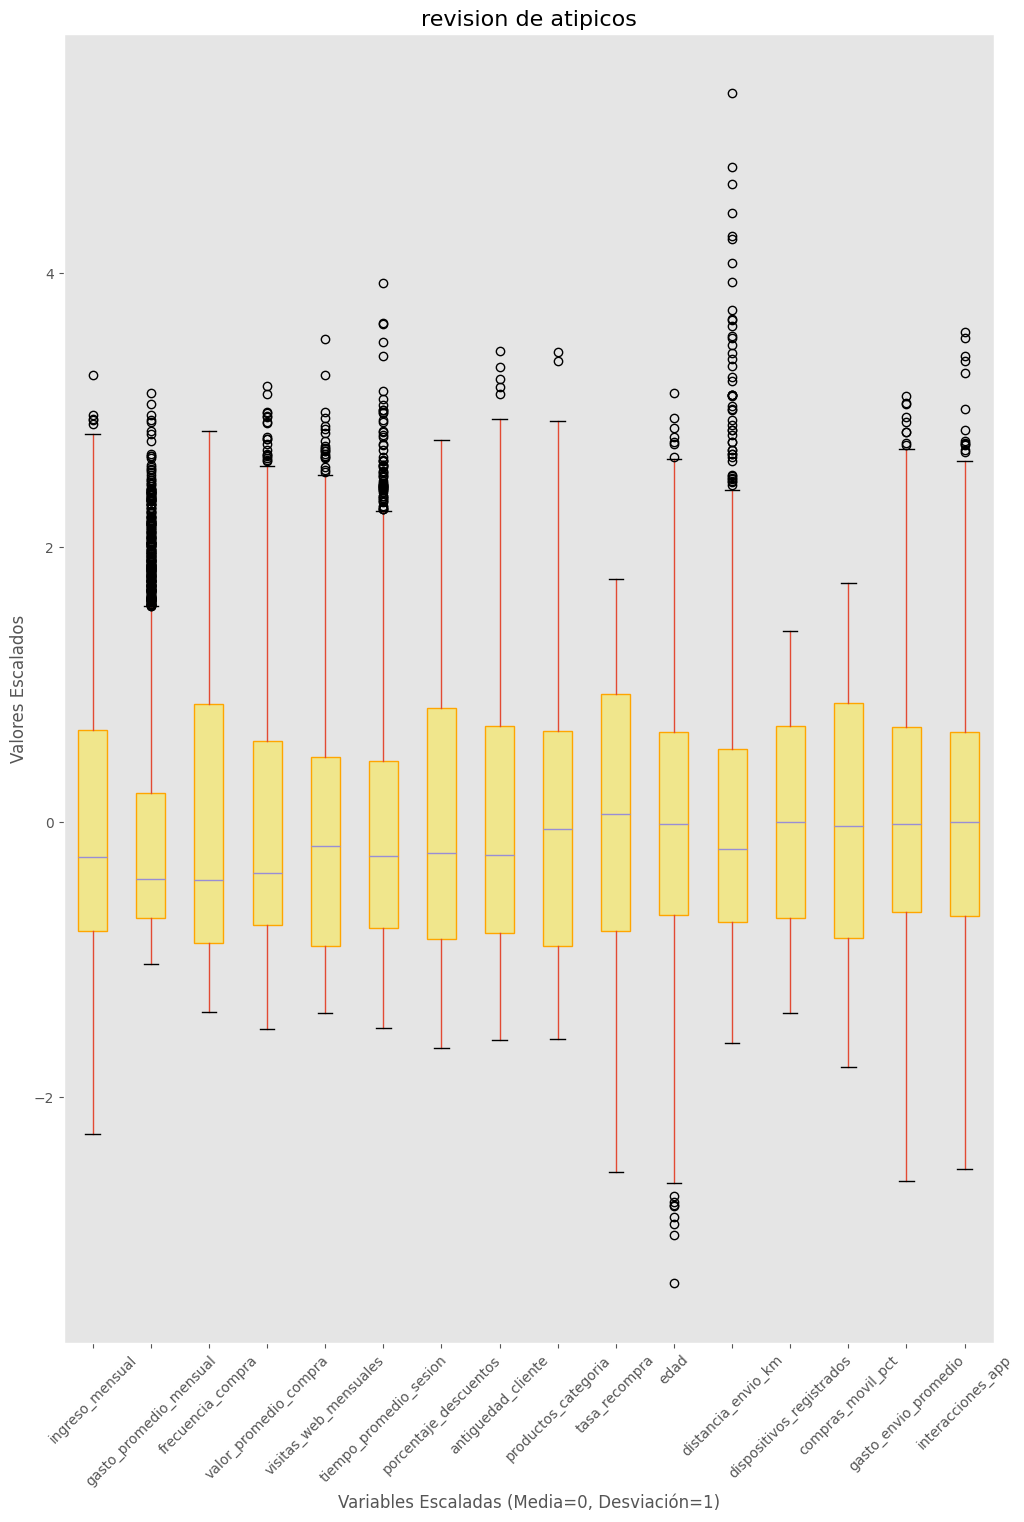

In [37]:
revision_atipicos = ["ingreso_mensual", "gasto_promedio_mensual", "frecuencia_compra",
    "valor_promedio_compra", "visitas_web_mensuales", "tiempo_promedio_sesion",
    "porcentaje_descuentos", "antiguedad_cliente", "productos_categoria",
    "tasa_recompra", "edad", "distancia_envio_km",
    "dispositivos_registrados", "compras_movil_pct", "gasto_envio_promedio",
    "interacciones_app"]
plt.figure(figsize=(12, 17))

# 3. Creamos el diagrama de bigotes
scaler = StandardScaler()

datos_escalados = scaler.fit_transform(data[revision_atipicos])
data_temporal = pd.DataFrame(datos_escalados, columns=revision_atipicos)

# 3. Configuramos y dibujamos el gráfico con los datos escalados
plt.figure(figsize=(12, 17))
data_temporal.boxplot(grid=False, patch_artist=True,
                     boxprops=dict(facecolor='khaki', color='orange'))

# 4. Detalles estéticos
plt.title('revision de atipicos', fontsize=16)
plt.xlabel('Variables Escaladas (Media=0, Desviación=1)', fontsize=12)
plt.ylabel('Valores Escalados', fontsize=12)
plt.xticks(rotation=45)

plt.show()

duplicados

In [38]:
data.duplicated().sum()

np.int64(0)

arreglar duplicadops

In [39]:
data[data.duplicated(keep=False)]

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app


arreglar inconcistentes

In [40]:
columns_to_correct = ["ingreso_mensual","gasto_promedio_mensual","frecuencia_compra","valor_promedio_compra","visitas_web_mensuales","tiempo_promedio_sesion",
 "porcentaje_descuentos","antiguedad_cliente","productos_categoria","tasa_recompra","edad","distancia_envio_km","dispositivos_registrados",
 "compras_movil_pct","gasto_envio_promedio","interacciones_app"]

for col in columns_to_correct:
    data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


In [41]:
# Detectar inconsistencias nuevamente después de la corrección
inconsistentes_corregido = data[
    (data["ingreso_mensual"] < 0) |
    (data["gasto_promedio_mensual"] < 0) |
    (data["frecuencia_compra"] < 0) |
    (data["valor_promedio_compra"] < 0) |
    (data["visitas_web_mensuales"] < 0) |
    (data["tiempo_promedio_sesion"] < 0) |
    (data["porcentaje_descuentos"] < 0) |
    (data["antiguedad_cliente"] < 0) |
    (data["productos_categoria"] < 0) |
    (data["tasa_recompra"] < 0) |
    (data["edad"] < 0) |
    (data["distancia_envio_km"] < 0) |
    (data["dispositivos_registrados"] < 0) |
    (data["compras_movil_pct"] < 0) |
    (data["gasto_envio_promedio"] < 0) |
    (data["interacciones_app"] < 0)
]
print("Registros inconsistentes encontrados después de la corrección:")
display(inconsistentes_corregido)

if inconsistentes_corregido.empty:
    print("No se encontraron inconsistencias de valores negativos después de la corrección")
else:
    print("Aún existen inconsistencias, revisar la lógica.")

Registros inconsistentes encontrados después de la corrección:


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app


No se encontraron inconsistencias de valores negativos después de la corrección


arreglar atipicos

In [42]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [43]:
data.describe().columns

Index(['cliente_id', 'ingreso_mensual', 'gasto_promedio_mensual',
       'frecuencia_compra', 'valor_promedio_compra', 'visitas_web_mensuales',
       'tiempo_promedio_sesion', 'porcentaje_descuentos', 'antiguedad_cliente',
       'productos_categoria', 'tasa_recompra', 'edad', 'distancia_envio_km',
       'dispositivos_registrados', 'compras_movil_pct', 'gasto_envio_promedio',
       'interacciones_app'],
      dtype='object')

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.01, 0.01))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

arreglar nulos

In [45]:
data = data.fillna(data.mean())

empieza lo de verdad

In [46]:
# Estandariza nombres de columnas
data.columns = data.columns.str.lower().str.replace(" ", "_", regex=True)
data.columns

Index(['cliente_id', 'ingreso_mensual', 'gasto_promedio_mensual',
       'frecuencia_compra', 'valor_promedio_compra', 'visitas_web_mensuales',
       'tiempo_promedio_sesion', 'porcentaje_descuentos', 'antiguedad_cliente',
       'productos_categoria', 'tasa_recompra', 'edad', 'distancia_envio_km',
       'dispositivos_registrados', 'compras_movil_pct', 'gasto_envio_promedio',
       'interacciones_app'],
      dtype='object')

In [47]:
data.query("ingreso_mensual < 0 or gasto_promedio_mensual < 0 or frecuencia_compra < 0")

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app


En este ejemplo, `ingreso_mensual`, `gasto_promedio_mensual` y `frecuencia_compra` son nombres de columnas reales de tu DataFrame. Deberías usar las columnas que sean relevantes para tu análisis de datos en particular.

In [48]:
data.query("ingreso_mensual > 100 or gasto_promedio_mensual > 100 or frecuencia_compra > 100")

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1131,3064.673693,120.046921,3.912038,46.805235,7.178476,4.766758,49.022936,10.734285,1.999530,38.431895,35.176502,12.934715,2,70.755851,5.580644,21.876419
1996,1295,4731.210237,139.028184,3.405505,67.368534,6.704609,5.440605,40.673940,7.415691,2.562903,43.193565,46.491302,46.832099,3,45.565464,5.080104,22.399950
1997,861,1723.045879,334.538794,10.872301,23.929503,26.520036,8.418260,65.133048,28.567377,5.162229,63.272365,60.652033,10.689774,4,78.039953,13.974822,21.233245
1998,1460,4409.785228,147.175735,2.861279,36.103718,8.978821,4.165788,22.339201,6.839567,1.119137,51.554097,44.975756,38.010825,1,30.475159,5.028416,44.955724


In [49]:
def view_graph_interactive(data, x :str, y :str, hover : str, title : str) -> None:
    """ Muestra un gráfico interactivo considerando 3 columnas

    x str : nombre de la columna asociada al eje X
    y str : nombre de la columna asociada al eje Y
    hover str :nombre de la columna que se mostrará al pasar el mouse por la gráfica

    returns None
    """
    fig = px.scatter(data, x = x, y = y, color = hover,
                 hover_name = data[hover].values,  width = 600, height = 600,
                 labels = {'x' : x, 'y' : y, hover : hover}, title = title)
    fig.show()

In [50]:
features = ["ingreso_mensual","gasto_promedio_mensual","frecuencia_compra","valor_promedio_compra","visitas_web_mensuales","tiempo_promedio_sesion",
 "porcentaje_descuentos","antiguedad_cliente","productos_categoria","tasa_recompra","edad","distancia_envio_km","dispositivos_registrados",
 "compras_movil_pct","gasto_envio_promedio","interacciones_app"]
view_graph_interactive(data[features], x="ingreso_mensual",
                       y="gasto_promedio_mensual", hover="frecuencia_compra",title="Relación entre puntajes")

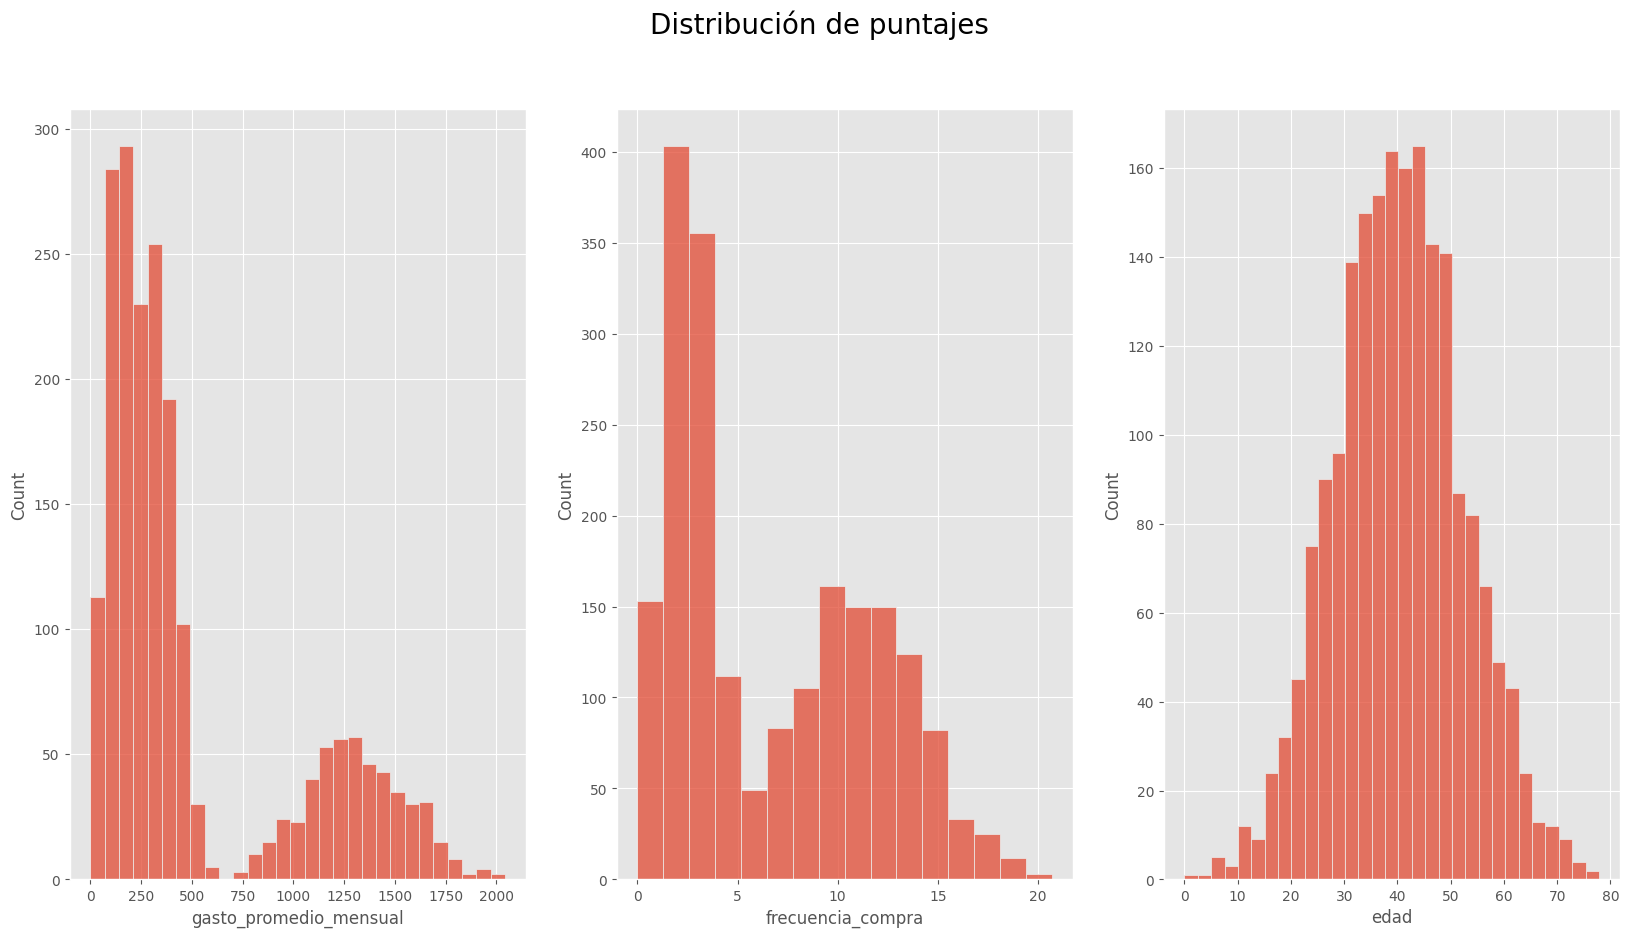

In [51]:
fig, ax = plt.subplots(1,3)
plt.suptitle("Distribución de puntajes", fontsize=20, horizontalalignment="center")
i = 0
for column in ['gasto_promedio_mensual', 'frecuencia_compra', 'edad']:
  sb.histplot(data[column], ax = ax[i], kde=False)
  i+=1
plt.show()

## Aplicación del algoritmo


In [52]:
features_num = ["ingreso_mensual","gasto_promedio_mensual","frecuencia_compra","valor_promedio_compra","visitas_web_mensuales","tiempo_promedio_sesion",
 "porcentaje_descuentos","antiguedad_cliente","productos_categoria","tasa_recompra","edad","distancia_envio_km","dispositivos_registrados",
 "compras_movil_pct","gasto_envio_promedio","interacciones_app"]
features_cat = []
# Preprocesamiento: escala lo numérico y codifica lo categórico
preprocessor_for_k = ColumnTransformer([
    ("num", StandardScaler(), features_num),
   ("cat", OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False), features_cat)
])

In [53]:
features = features_num+ features_cat
features

['ingreso_mensual',
 'gasto_promedio_mensual',
 'frecuencia_compra',
 'valor_promedio_compra',
 'visitas_web_mensuales',
 'tiempo_promedio_sesion',
 'porcentaje_descuentos',
 'antiguedad_cliente',
 'productos_categoria',
 'tasa_recompra',
 'edad',
 'distancia_envio_km',
 'dispositivos_registrados',
 'compras_movil_pct',
 'gasto_envio_promedio',
 'interacciones_app']

In [54]:
X_transformed = preprocessor_for_k.fit_transform(data[features])

In [55]:
# Experimentar con valor de k
inertias = []
silhouettes = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=29)
    km.fit(X_transformed)
    # Almacena inercias y el valor de una métrica
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_transformed, km.labels_))

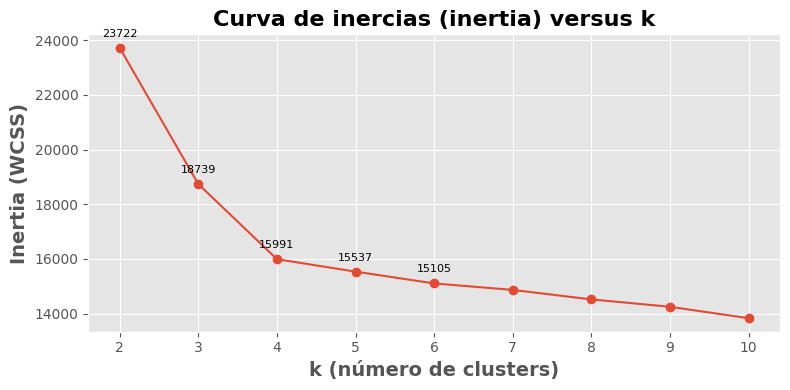

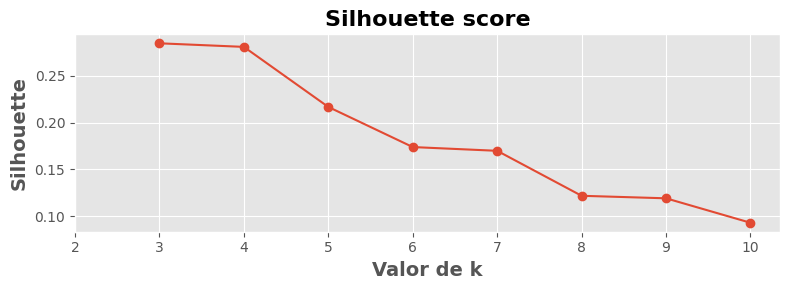

In [56]:
# Graficar inertias (Elbow plot)
range_k = range(2, 11)
plt.figure(figsize=(8,4))
plt.plot(list(range_k), inertias, marker='o')
plt.title("Curva de inercias (inertia) versus k", fontsize=16, fontweight="bold")
plt.xlabel("k (número de clusters)", fontsize=14, fontweight="bold")
plt.ylabel("Inertia (WCSS)", fontsize=14, fontweight="bold")
plt.xticks(list(range_k))

for k_val, val in zip(list(range_k), inertias):
    if k_val <= 6:
        plt.annotate(f"{val:.0f}", (k_val, val), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# Grafica el índice de silhoutte
plt.figure(figsize=(8,3))
plt.plot(list(range_k)[1:], silhouettes[1:], marker='o')
plt.title("Silhouette score", fontsize=16, fontweight="bold")
plt.xlabel("Valor de k", fontsize=14, fontweight="bold")
plt.ylabel("Silhouette", fontsize=14, fontweight="bold")
plt.xticks(list(range_k))
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
# Obtiene el mejor valor de k
kl = KneeLocator(range_k, inertias, curve="convex", direction="decreasing")
print(f"El codo está en k = {kl.elbow}")
print(f"Valor de la inercia = {kl.all_elbows_y[0]: .2f}")

El codo está en k = 4
Valor de la inercia =  15991.13


## Ejecución del algoritmo

Se ejecuta el algoritmo para la cantidad de clusters indicada por `KneeLocator` y se obtienen las etiquetas y los centroides.

In [58]:
# Ahora si el preprocessor definitivo
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False), features_cat)
])

pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("kmeans", KMeans(n_clusters=kl.elbow, random_state=29))
])

In [59]:
pipeline_final.fit(data[features])

clusters = pipeline_final.predict(data[features])
data["cluster"] = clusters

In [60]:
data.head()

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app,cluster
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957,2
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043,0
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213,1
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341,3
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139,1


In [61]:
# Obtener el modelo entrenado
kmeans = pipeline_final.named_steps["kmeans"]

# Obtener los centroides en el espacio transformado
centroides_transformados = kmeans.cluster_centers_

print(centroides_transformados)

[[ 1.37958098e+00  1.62762774e+00  1.08967478e+00  1.52775664e+00
  -3.09923374e-01 -6.13196489e-02 -1.03612612e+00  1.27597064e+00
   3.14316591e-01  1.19978020e+00 -1.02130755e-02 -2.77923810e-02
  -5.92151527e-03  4.31481457e-02  1.11836541e-02  7.37610073e-04]
 [-6.17155892e-01 -7.89902945e-01 -9.82820575e-01 -6.00912833e-01
  -1.13618952e+00 -1.01211223e+00  3.20077681e-03 -1.00059913e+00
  -1.12613028e+00 -1.08906613e+00  1.51229560e-03  5.25696850e-02
   6.23500725e-02 -4.42147573e-02  4.38132995e-02 -2.33903498e-02]
 [ 1.09473370e-01 -5.30294727e-01 -7.68788141e-01 -1.26956604e-01
   1.43580995e+00  1.41238243e+00 -3.84296774e-01 -5.10491223e-01
   1.21526024e+00 -4.77520618e-01  1.29164541e-02  1.19384368e-02
  -3.93606603e-02 -3.86678677e-04 -4.50128045e-02 -2.72115416e-02]
 [-8.71898456e-01 -3.07430072e-01  6.61933940e-01 -7.99887199e-01
   1.03029455e-02 -3.38950560e-01  1.41722212e+00  2.35119711e-01
  -4.03446550e-01  3.66806550e-01 -4.21567420e-03 -3.67157409e-02
  -1.70

In [62]:
def obtener_centroides_originales(pipeline, features_num, features_cat) -> pd.DataFrame:
    """
    Reconstruye los centroides de K-Means en su escala original

    Parámetros:
        pipeline      -> pipeline entrenado que contiene "preprocessor" y "kmeans"
        features_num  -> lista de columnas numéricas originales
        features_cat  -> lista de columnas categóricas originales

    Retorna:
        DataFrame con los centroides en la escala original.
    """

    # Extraer transformador y modelo
    preprocessor = pipeline.named_steps["preprocessor"]
    kmeans = pipeline.named_steps["kmeans"]

    # Centroides transformados
    centroides_trans = kmeans.cluster_centers_

    # Lista donde guardar centroides reconstruidos
    centroides_recuperados = []

    # Obtener transformadores del ColumnTransformer
    transformers_info = preprocessor.transformers_

    # Procesa cada centroide transformado
    for row_transformed in centroides_trans:
        original_row_values = []
        current_index_in_transformed_row = 0

        for name, transformer_instance, assigned_cols in transformers_info:
            # Only process if the transformer was assigned to actual columns.
            # If assigned_cols is empty (e.g., for OneHotEncoder with empty features_cat),
            # the transformer was not fitted and inverse_transform would fail.
            if assigned_cols:
                # Determine the number of output features this transformer produces
                if hasattr(transformer_instance, 'get_feature_names_out'):
                    num_output_features = len(transformer_instance.get_feature_names_out())
                elif hasattr(transformer_instance, 'n_features_out_'):
                     num_output_features = transformer_instance.n_features_out_
                elif hasattr(transformer_instance, 'categories_'): # Fallback for OneHotEncoder
                    num_output_features = sum(len(cat) for cat in transformer_instance.categories_)
                else: # For other transformers like StandardScaler, assume 1 output per input
                    num_output_features = len(assigned_cols)

                # Extract the segment of the transformed row corresponding to this transformer
                slice_of_transformed_row = row_transformed[current_index_in_transformed_row : current_index_in_transformed_row + num_output_features]

                # Inverse transform the segment
                slice_original = transformer_instance.inverse_transform([slice_of_transformed_row])[0]

                original_row_values.extend(slice_original)
                current_index_in_transformed_row += num_output_features
            # If assigned_cols is empty, this transformer wasn't fitted and produced no output.
            # We skip inverse transforming it, and current_index_in_transformed_row doesn't advance,
            # and no values are added to original_row_values for this transformer.

        centroides_recuperados.append(original_row_values)

    # Armar nombres finales de columnas
    columnas_finales = features_num + features_cat

    # Convertir a DataFrame
    data_centroides = pd.DataFrame(centroides_recuperados, columns=columnas_finales)

    return data_centroides


In [63]:
# Obtiene los centroides originales
df_centroides = obtener_centroides_originales(
    pipeline_final,
    features_num,
    features_cat
)

df_centroides

,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,7517.928187,1305.319888,12.081016,151.152167,34.854095,14.898922,14.934054,39.965143,8.155166,90.314137,40.183412,29.872172,2.990,56.689857,8.029174,24.856785
1,3514.075650,119.087562,1.943835,45.046605,8.218190,5.041743,40.280676,8.215332,1.962904,35.191956,40.324066,31.281391,3.088,54.462346,8.128879,24.619391
2,4971.111106,246.471947,2.990730,68.671406,91.130376,30.177274,30.830566,15.050542,12.028186,49.919779,40.460867,30.568886,2.942,55.579840,7.857457,24.581794
3,3003.266401,355.827026,9.988811,35.128538,45.177061,12.020631,74.765171,25.449084,5.069611,70.253671,40.255355,29.715693,2.974,55.626754,7.964492,25.340140


In [64]:
def graficar_clusters_3d(df : pd.DataFrame, df_centroides: pd.DataFrame,
                         x: str, y = str, z = str,
                         cluster_col="cluster",
                         ) -> None:
    """
    Grafica los datos y centroides en 3D.

    Parámetros:
        df              -> DataFrame original con columna "cluster"
        df_centroides   -> centroides recuperados en escala original
        cluster_col     -> nombre de la columna con el cluster asignado
        x, y, z         -> nombres de las columnas numéricas a graficar
    """

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Graficar puntos del dataset
    scatter = ax.scatter(
        df[x],
        df[y],
        df[z],
        c=df[cluster_col],
        cmap='tab10',
        s=30,
        alpha=0.6
    )

    # Graficar centroides
    ax.scatter(
        df_centroides[x],
        df_centroides[y],
        df_centroides[z],
        s=300,
        c="black",
        marker="X",
        edgecolor="white",
        linewidth=1.5,
        label="Centroides"
    )

    ax.set_xlabel(x, fontsize=16, fontweight="bold")
    ax.set_ylabel(y, fontsize=16, fontweight="bold")
    ax.set_zlabel(z, fontsize=16, fontweight="bold")

    ax.set_title("Clusters en 3D con centroides originales", fontsize=16, fontweight="bold")
    ax.legend()

    plt.show()


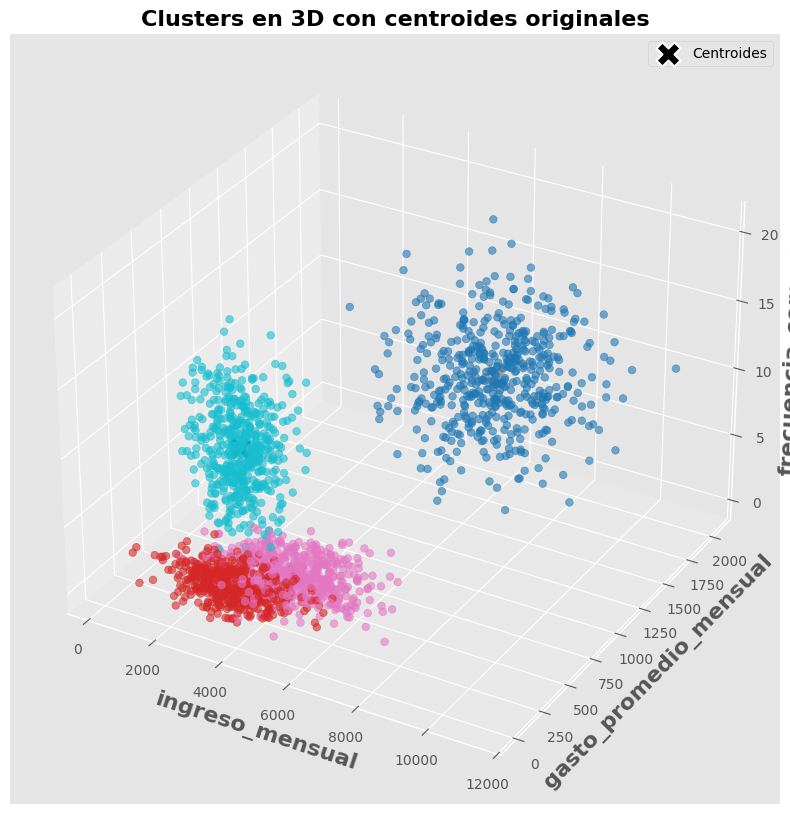

In [65]:
graficar_clusters_3d(
    data,
    df_centroides,
    cluster_col="cluster",
    x="ingreso_mensual",
    y="gasto_promedio_mensual",
    z="frecuencia_compra"
)

## Clasificación de nuevas muestras

In [66]:
def predecir_cluster(nuevos_valores: np.array, pipeline_entrenado):
    """
    nuevos_valores: dict o DataFrame con las columnas originales
    pipeline_entrenado: pipeline final (preprocesamiento + KMeans)

    Retorna: cluster asignado por KMeans
    """
    df_nuevo = pd.DataFrame([nuevos_valores])
    cluster = pipeline_entrenado.predict(df_nuevo)
    return cluster[0]


In [67]:
features

['ingreso_mensual',
 'gasto_promedio_mensual',
 'frecuencia_compra',
 'valor_promedio_compra',
 'visitas_web_mensuales',
 'tiempo_promedio_sesion',
 'porcentaje_descuentos',
 'antiguedad_cliente',
 'productos_categoria',
 'tasa_recompra',
 'edad',
 'distancia_envio_km',
 'dispositivos_registrados',
 'compras_movil_pct',
 'gasto_envio_promedio',
 'interacciones_app']

## Caso 1

In [68]:
nuevo_registro = {
    "ingreso_mensual": 50,
    "gasto_promedio_mensual": 35,
    "frecuencia_compra": 0,
    "valor_promedio_compra": 0,
    "visitas_web_mensuales": 0,
    "tiempo_promedio_sesion": 0,
    "porcentaje_descuentos": 0,
    "antiguedad_cliente": 42,
    "productos_categoria": 0,
    "tasa_recompra": 0,
    "edad": 0,
    "distancia_envio_km": 0,
    "dispositivos_registrados":0,
    "compras_movil_pct": 0,
    "gasto_envio_promedio": 0,
    "interacciones_app": 0
}

cluster_predicho = predecir_cluster(nuevo_registro, pipeline_final)
print(f"El nuevo registro pertenece al cluster: {cluster_predicho}")

El nuevo registro pertenece al cluster: 1


In [69]:

selected_centroid_features = [
    "ingreso_mensual",
    "gasto_promedio_mensual",
    "frecuencia_compra",
    "valor_promedio_compra"
]

# Muestra solo las columnas seleccionadas de los centroides
display(df_centroides[selected_centroid_features])

,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra
0,7517.928187,1305.319888,12.081016,151.152167
1,3514.075650,119.087562,1.943835,45.046605
2,4971.111106,246.471947,2.990730,68.671406
3,3003.266401,355.827026,9.988811,35.128538


## Justificación

Esta predicción permite identificar si este nuevo usuario entrará al clúster de "Clientes VIP/Fidelizados" o al de "Compradores Esporádicos de Bajo Gasto".



In [70]:
# Revisa características de cluster al que pertenece la nueva observación
selected_features = [
    "ingreso_mensual",
    "gasto_promedio_mensual",
    "frecuencia_compra",
    "valor_promedio_compra"

]
data.query(f"cluster == {cluster_predicho}")[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
ingreso_mensual,500.0,3514.075650,932.979013,198.780033,2895.234664,3488.409795,4069.633880,6266.160368
gasto_promedio_mensual,500.0,119.087562,50.458298,0.000000,83.624379,120.934924,153.022965,265.516913
frecuencia_compra,500.0,1.943835,1.001048,0.000000,1.257133,1.940127,2.555510,4.929544
valor_promedio_compra,500.0,45.046605,15.172638,0.000000,34.982804,44.949991,55.996577,86.146837


## Caso 2

In [71]:
nuevo_registro = {
   "ingreso_mensual": 70,
    "gasto_promedio_mensual": 70,
    "frecuencia_compra": 70,
    "valor_promedio_compra": 70,
    "visitas_web_mensuales": 70,
    "tiempo_promedio_sesion": 70,
    "porcentaje_descuentos": 70,
    "antiguedad_cliente": 70,
    "productos_categoria": 70,
    "tasa_recompra": 70,
    "edad": 70,
    "distancia_envio_km":70,
    "dispositivos_registrados":70,
    "compras_movil_pct": 70,
    "gasto_envio_promedio": 70,
    "interacciones_app": 70

}

cluster_predicho = predecir_cluster(nuevo_registro, pipeline_final)
print("El nuevo registro pertenece al cluster:", cluster_predicho)



El nuevo registro pertenece al cluster: 0


In [72]:
selected_centroid_features = [
  "edad",
    "dispositivos_registrados",
    "compras_movil_pct",
    "interacciones_app"
]

# Muestra solo las columnas seleccionadas de los centroides
display(df_centroides[selected_centroid_features])

,edad,dispositivos_registrados,compras_movil_pct,interacciones_app
0,40.183412,2.990,56.689857,24.856785
1,40.324066,3.088,54.462346,24.619391
2,40.460867,2.942,55.579840,24.581794
3,40.255355,2.974,55.626754,25.340140


## Justificación

Permite saber cómo comunicarse con este cliente. Agruparlo nos dirá si es un usuario "Mobile nativo atraído por ofertas" o un "Usuario tradicional".

In [73]:
selected_features2 = [
    "edad",
    "dispositivos_registrados",
    "compras_movil_pct",
    "interacciones_app"
]
data.query(f"cluster == {cluster_predicho}")[selected_features2].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,500.0,40.183412,12.088885,0.00000,32.365937,40.377238,47.951165,77.829553
dispositivos_registrados,500.0,2.990000,1.420541,1.00000,2.000000,3.000000,4.000000,5.000000
compras_movil_pct,500.0,56.689857,24.943512,10.07077,35.472292,55.889129,77.413254,99.982099
interacciones_app,500.0,24.856785,9.662620,0.00000,18.270030,24.954682,31.702055,59.546753
